### Problem 1: Divide and Conquer – Merge Sort

List before sorting: [55, 23, 89, 12, 5, 78, 34]
List after sorting: [5, 12, 23, 34, 55, 78, 89]


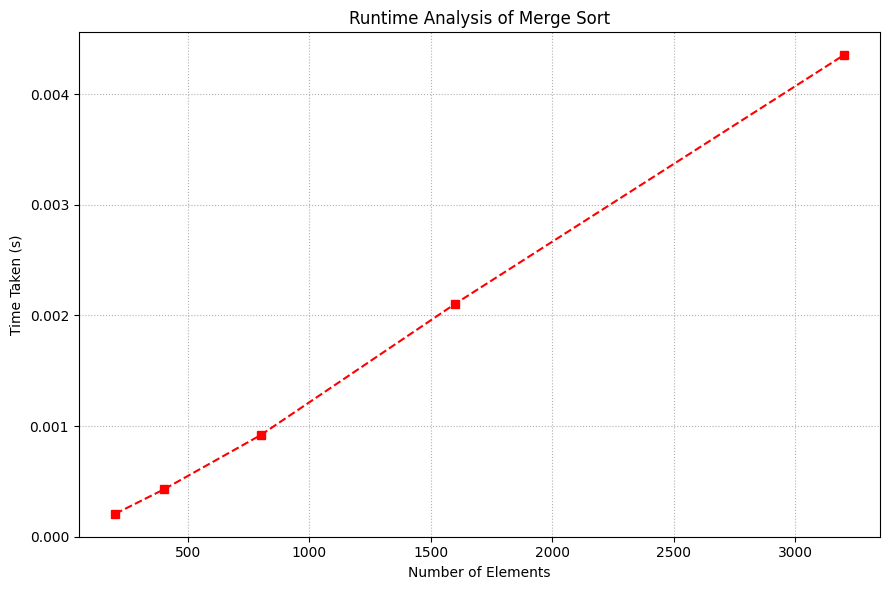

In [1]:
import time
import random
import matplotlib.pyplot as plt

def do_merge_sort(array):
    if len(array) <= 1:
        return array
    
    middle = len(array) // 2
    left_half = do_merge_sort(array[:middle])
    right_half = do_merge_sort(array[middle:])
    
    return merge_halves(left_half, right_half)

def merge_halves(left_half, right_half):
    merged = []
    l_idx = 0
    r_idx = 0
    
    while l_idx < len(left_half) and r_idx < len(right_half):
        if left_half[l_idx] <= right_half[r_idx]:
            merged.append(left_half[l_idx])
            l_idx += 1
        else:
            merged.append(right_half[r_idx])
            r_idx += 1
            
    merged.extend(left_half[l_idx:])
    merged.extend(right_half[r_idx:])
    return merged

test_list = [55, 23, 89, 12, 5, 78, 34]
print("List before sorting:", test_list)
print("List after sorting:", do_merge_sort(test_list))

input_sizes = [200, 400, 800, 1600, 3200]
exec_times = []

for size in input_sizes:
    random_array = [random.randint(1, 10000) for _ in range(size)]
    
    start_time = time.perf_counter()   
    do_merge_sort(random_array)
    end_time = time.perf_counter()
    
    exec_times.append(end_time - start_time)

plt.figure(figsize=(9, 6))
plt.plot(input_sizes, exec_times, marker='s', color='r', linestyle='--')
plt.xlabel("Number of Elements")
plt.ylabel("Time Taken (s)")
plt.title("Runtime Analysis of Merge Sort")
plt.grid(True, linestyle=':')
plt.tight_layout()
plt.show()

### Problem 2: Sorting Performance Comparison (Merge Sort & Bubble Sort)


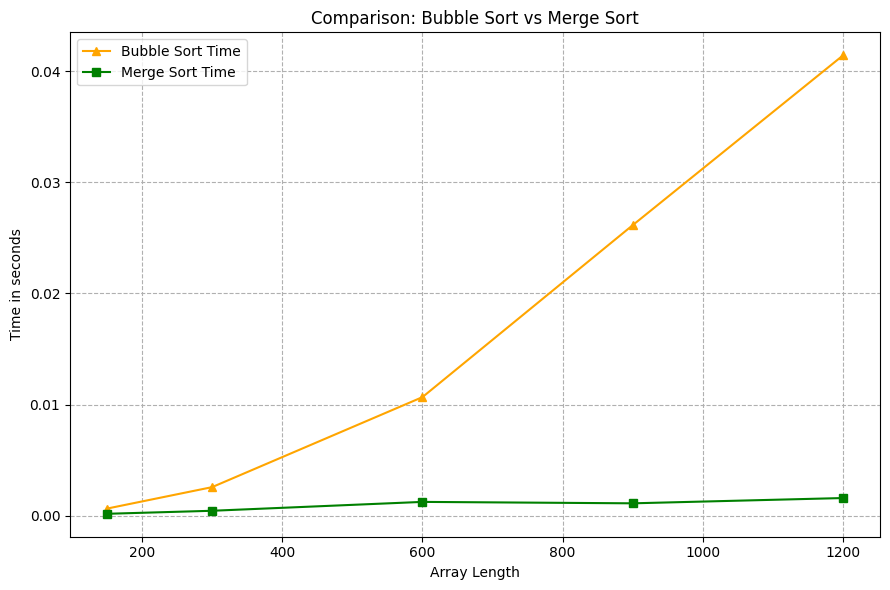

In [2]:
def my_bubble_sort(lst):
    length = len(lst)
    for i in range(length):
        swapped = False
        for j in range(0, length - i - 1):
            if lst[j] > lst[j+1]:
                lst[j], lst[j+1] = lst[j+1], lst[j]
                swapped = True
        if not swapped:
            break
    return lst

# Using the merge sort defined earlier
test_sizes = [150, 300, 600, 900, 1200]

b_times = []
m_times = []

for s in test_sizes:
    test_arr = [random.randint(1, 10000) for _ in range(s)]

    # Time Bubble Sort
    t0 = time.perf_counter()
    my_bubble_sort(test_arr.copy())
    b_times.append(time.perf_counter() - t0)

    # Time Merge Sort
    t1 = time.perf_counter()
    do_merge_sort(test_arr.copy())
    m_times.append(time.perf_counter() - t1)

plt.figure(figsize=(9, 6))
plt.plot(test_sizes, b_times, marker='^', color='orange', label='Bubble Sort Time')
plt.plot(test_sizes, m_times, marker='s', color='green', label='Merge Sort Time')
plt.xlabel("Array Length")
plt.ylabel("Time in seconds")
plt.title("Comparison: Bubble Sort vs Merge Sort")
plt.legend(loc="upper left")
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

### Problem 3: Greedy Algorithm (Fractional Knapsack)

In [3]:
item_values = [50, 100, 150, 200]
item_weights = [10, 20, 30, 40]
max_capacity = 60

def get_max_fractional_value(vals, wts, W):
    # Combine values and weights and compute value to weight ratio
    combined = []
    for i in range(len(vals)):
        combined.append({
            'value': vals[i],
            'weight': wts[i],
            'ratio': vals[i] / wts[i]
        })
        
    # Sort items based on ratio in descending order using built-in sort
    combined.sort(key=lambda x: x['ratio'], reverse=True)

    max_val = 0.0

    for item in combined:
        if W >= item['weight']:
            max_val += item['value']
            W -= item['weight']
        else:
            fraction = W / item['weight']
            max_val += item['value'] * fraction
            break

    return max_val

max_profit = get_max_fractional_value(item_values, item_weights, max_capacity)
print("Total maximum value we can carry:", max_profit)

Total maximum value we can carry: 300.0


### Problem 4: Dynammic Programming (0/1 Knapsack)


In [4]:
v_list = [50, 100, 150, 200]
w_list = [10, 20, 30, 40]
W_max = 60

def solve_01_knapsack(max_w, weights_arr, values_arr):
    n_items = len(values_arr)
    # create a 2D array matrix and initialize with 0
    memo = []
    for _ in range(n_items + 1):
        memo.append([0] * (max_w + 1))

    for i in range(1, n_items + 1):
        for w in range(1, max_w + 1):
            current_weight = weights_arr[i-1]
            current_value = values_arr[i-1]
            
            if current_weight <= w:
                memo[i][w] = max(current_value + memo[i-1][w - current_weight], memo[i-1][w])
            else:
                memo[i][w] = memo[i-1][w]

    return memo[n_items][max_w]

ans = solve_01_knapsack(W_max, w_list, v_list)
print("Maximum Profit for 0/1 Knapsack:", ans)

Maximum Profit for 0/1 Knapsack: 300
